# Finding non-principal branches of the QRE correspondence

Gambit computes logit quantal response equilibria (LQRE) ([McKPal95](https://gambitproject.readthedocs.io/en/latest/biblio.html#general-game-theory-articles-and-texts)) by path-following:
`logit_solve` and `logit_solve_branch` trace the branch of the LQRE correspondence which starts at the centroid at $\lambda = 0$, called the *principal branch*.
In many games the correspondence also has other branches.
These are not connected to the principal branch, so they cannot be reached by any method which follows the correspondence from the centroid.

[Bla24](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria) proposes a simulation-based method which in principle can locate points near *any* branch:
sample strategy profiles from a probability density constructed to concentrate near the graph of the correspondence.
A sampled point close to a branch can then be polished to high accuracy using Newton's method, and the branch containing it can be traced out from there.

This notebook illustrates the method on a small example, using Gambit for the game representation and the expected payoff calculations.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize

import pygambit as gbt

## A game whose correspondence has a second branch

We use a symmetric $2\times 2$ stag hunt.
Hunting stag pays 3 if the other player also hunts stag, and 0 otherwise; hunting hare pays 2 regardless of what the other player does.
The game has three Nash equilibria: (Stag, Stag), (Hare, Hare), and a symmetric mixed equilibrium in which each player hunts stag with probability $\frac{2}{3}$.

In [2]:
g = gbt.Game.from_arrays(
    [[3, 0], [2, 2]],
    [[3, 2], [0, 2]],
    title="Stag hunt",
)
for player in g.players:
    stag, hare = player.strategies
    stag.label = "Stag"
    hare.label = "Hare"
gbt.nash.enummixed_solve(g).equilibria

[[[Rational(1, 1), Rational(0, 1)], [Rational(1, 1), Rational(0, 1)]],
 [[Rational(2, 3), Rational(1, 3)], [Rational(2, 3), Rational(1, 3)]],
 [[Rational(0, 1), Rational(1, 1)], [Rational(0, 1), Rational(1, 1)]]]

The principal branch starts from uniform play at $\lambda = 0$.
Following it with `logit_solve_branch`, we see that as $\lambda$ grows it converges to (Hare, Hare) — the risk-dominant equilibrium.
The other two equilibria are invisible to this computation.

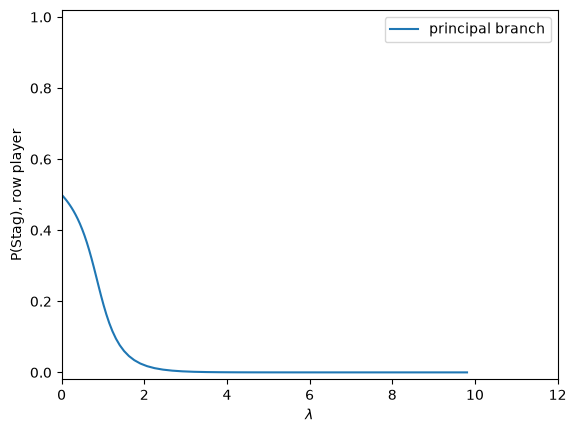

In [3]:
row, col = g.players
row_stag = row.strategies["Stag"]
principal = np.array([[q.lam, q.profile[row_stag]] for q in gbt.qre.logit_solve_branch(g)])

fig, ax = plt.subplots()
ax.plot(principal[:, 0], principal[:, 1], color="C0", label="principal branch")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("P(Stag), row player")
ax.set_xlim(0, 12)
ax.set_ylim(-0.02, 1.02)
ax.legend()
plt.show()

## A density which concentrates on the correspondence

A pair $(\sigma, \lambda)$ is a LQRE if for every player $i$

$$\sigma_i = \operatorname{softmax}(\lambda\, v_i(\sigma)),$$

where $v_i(\sigma)$ is the vector of expected payoffs to player $i$'s pure strategies when the others play according to $\sigma$.
[Bla24](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria) measures how far a profile is from satisfying these conditions with the penalty

$$\operatorname{obj}(\sigma, \lambda) \;=\; -\sum_i \bigl\lVert \sigma_i - \operatorname{softmax}(\lambda\, v_i(\sigma)) \bigr\rVert^2,$$

which is zero exactly on the correspondence and negative elsewhere.
Rather than treating $\lambda$ as a free parameter, it can be *eliminated* ([Bla24](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria), Section 3): given $\sigma$, the logit conditions are linear in $\lambda$ on the log-odds scale, so the least-squares fit has the closed form

$$\lambda^*(\sigma) = \max\left(0,\; \frac{\sum_i \sum_a x_{ia} y_{ia}}{\sum_i \sum_a x_{ia}^2}\right),$$

where $x_{ia}$ and $y_{ia}$ are the differences in expected payoff and in log probability between strategy $a$ and a fixed reference strategy of the same player.
We follow the author's implementation in the [online appendix](https://github.com/JamesBlandEcon/ApproxQRE) of [Bla24](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria).
Gambit's `strategy_value` provides the expected payoffs.

In [4]:
def softmax(x):
    """Map a vector of logits to a probability distribution, stably."""
    z = np.exp(x - np.max(x))
    return z / z.sum()


def strategy_values(game, probs):
    """Expected payoff to each pure strategy against the mixed profile `probs`.

    Returns one array per player, ordered as in `game.players`.
    """
    profile = game.mixed_strategy_profile([[float(p) for p in pr] for pr in probs])
    return [
        np.array([profile.strategy_value(s) for s in player.strategies])
        for player in game.players
    ]


def lambda_star(probs, values):
    """Closed-form least-squares lambda for a profile, from the logit conditions."""
    num = den = 0.0
    for pr, v in zip(probs, values, strict=True):
        y = np.log(pr[:-1]) - np.log(pr[-1])
        x = v[:-1] - v[-1]
        num += x @ y
        den += x @ x
    if den < 1e-12:  # all strategies payoff-equivalent: any lambda fits equally well
        return 0.0
    return max(num / den, 0.0)


def obj_fun(game, probs):
    """Bland's penalty objective; returns (obj, lambda*)."""
    values = strategy_values(game, probs)
    lam = lambda_star(probs, values)
    obj = -sum(np.sum((pr - softmax(lam * v)) ** 2) for pr, v in zip(probs, values, strict=True))
    return obj, lam

## Sampling near the correspondence

Draws from a density proportional to $\exp(w \cdot \operatorname{obj}(\sigma))$ concentrate near the set where $\operatorname{obj} = 0$, with the weight $w$ controlling how tightly.
[Bla24](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria) samples such densities using Hamiltonian Monte Carlo (Stan); a random-walk Metropolis sampler keeps this notebook self-contained.
Each chain starts from an independent uniformly-drawn profile, so chains can land on branches which are not connected to the centroid.

(The proposal walks on unconstrained log-odds, which implies a slightly different base measure than the uniform-on-the-simplex prior used by [Bla24](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria).
This is immaterial here: the draws serve only as approximate locations on the correspondence, not as posterior samples.)

In [5]:
PENALTY_WEIGHT = 10_000.0  # w; the value used in the online appendix of [Bla24]
STEP_SIZE = 0.15  # std. dev. of proposal increments in log-odds space


def sample_locus(game, rng, n_chains, n_iter):
    """Random-walk Metropolis on the penalised density.

    Returns one row per draw: the fitted lambda*, then each player's probability
    of their first strategy, then the value of the penalty objective.
    """
    draws = []
    for _ in range(n_chains):
        z = [np.log(rng.dirichlet(np.ones(len(p.strategies)))) for p in game.players]
        probs = [softmax(zi) for zi in z]
        obj, lam = obj_fun(game, probs)
        for _ in range(n_iter):
            z_prop = [zi + STEP_SIZE * rng.standard_normal(zi.shape) for zi in z]
            probs_prop = [softmax(zi) for zi in z_prop]
            obj_prop, lam_prop = obj_fun(game, probs_prop)
            if np.log(rng.uniform()) < PENALTY_WEIGHT * (obj_prop - obj):
                z, probs, obj, lam = z_prop, probs_prop, obj_prop, lam_prop
            draws.append([lam, *(pr[0] for pr in probs), obj])
    return np.array(draws)


rng = np.random.default_rng(20260722)
draws = sample_locus(g, rng, n_chains=12, n_iter=1_500)
on_locus = draws[draws[:, -1] > -1e-4]
len(on_locus), len(draws)

(15790, 18000)

Plotting the draws next to the principal branch reveals a second branch.

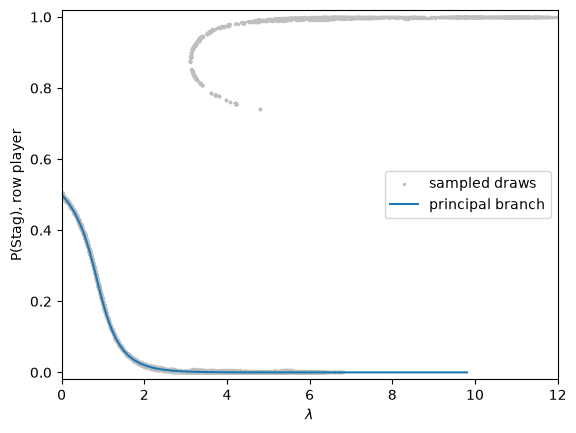

In [6]:
fig, ax = plt.subplots()
ax.scatter(on_locus[:, 0], on_locus[:, 1], s=2, color="0.75", label="sampled draws")
ax.plot(principal[:, 0], principal[:, 1], color="C0", label="principal branch")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("P(Stag), row player")
ax.set_xlim(0, 12)
ax.set_ylim(-0.02, 1.02)
ax.legend()
plt.show()

The second branch exists only above a minimum value of $\lambda$, where its two sides meet at a *fold*.
As $\lambda \to \infty$ the upper side converges to (Stag, Stag) and the lower side to the mixed equilibrium.

## Polishing a draw with Newton's method

A draw with $\operatorname{obj}$ near zero is only an approximate LQRE.
Fix $\lambda$ at the draw's $\lambda^*(\sigma)$; because probabilities on both sides of the fixed-point condition sum to one, dropping one component per player leaves a square nonlinear system, which `scipy.optimize.root` solves to machine precision in a few Newton-type iterations.

In [7]:
def pack(probs):
    """Per-player log-odds relative to the last strategy, concatenated."""
    return np.concatenate([np.log(pr[:-1]) - np.log(pr[-1]) for pr in probs])


def unpack(free, game):
    probs, k = [], 0
    for player in game.players:
        n = len(player.strategies)
        probs.append(softmax(np.concatenate([free[k:k + n - 1], [0.0]])))
        k += n - 1
    return probs


def qre_residual(free, game, lam):
    probs = unpack(free, game)
    values = strategy_values(game, probs)
    return np.concatenate(
        [(pr - softmax(lam * v))[:-1] for pr, v in zip(probs, values, strict=True)]
    )


def polish(game, probs, lam):
    """Newton-polish an approximate LQRE at fixed lambda; None if no convergence."""
    sol = scipy.optimize.root(qre_residual, pack(probs), args=(game, lam))
    return unpack(sol.x, game) if sol.success else None

Take the best draw on the upper side of the second branch and polish it.

In [8]:
principal_p = np.interp(on_locus[:, 0], principal[:, 0], principal[:, 1])
upper = on_locus[
    (np.abs(on_locus[:, 1] - principal_p) > 0.15)
    & (on_locus[:, 1] > 0.85)
    & (on_locus[:, 0] > 2) & (on_locus[:, 0] < 8)
]
lam_u, p_row, p_col, obj_u = upper[np.argmax(upper[:, 3])]
seed_upper = polish(g, [np.array([p_row, 1 - p_row]), np.array([p_col, 1 - p_col])], lam_u)
print(f"draw:     lambda* = {lam_u:.4f}, P(Stag) = {p_row:.4f}, obj = {obj_u:.2e}")
print(f"polished: P(Stag) = {seed_upper[0][0]:.6f}, "
      f"residual = {np.linalg.norm(qre_residual(pack(seed_upper), g, lam_u)):.2e}")

draw:     lambda* = 6.7779, P(Stag) = 0.9988, obj = -1.05e-12
polished: P(Stag) = 0.998835, residual = 0.00e+00


## Tracing the branch

From a polished point, the branch can be traced by stepping $\lambda$ in small increments, re-solving at each step from the previous solution.
This fixed-$\lambda$ continuation must stop at the fold, where the branch turns around in $\lambda$ and the Jacobian of the fixed-$\lambda$ system becomes singular.
(Gambit's own tracer avoids this by following the path by arclength instead — the approach described in [Tur05](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria).)

In [9]:
LAMBDA_STEP = 0.05
LAMBDA_MAX = 12.0


def trace_branch(game, probs, lam):
    """Follow a branch through (probs, lam) in both directions of lambda."""
    points = [(lam, probs[0][0])]
    for direction in (+1.0, -1.0):
        cur_probs, cur_lam = probs, lam
        while 0.0 < cur_lam + direction * LAMBDA_STEP < LAMBDA_MAX:
            nxt = polish(game, cur_probs, cur_lam + direction * LAMBDA_STEP)
            if nxt is None:
                break  # no nearby solution: we have hit a fold
            cur_lam += direction * LAMBDA_STEP
            cur_probs = nxt
            points.append((cur_lam, cur_probs[0][0]))
    return np.array(sorted(points))


branch_upper = trace_branch(g, seed_upper, lam_u)
print(f"upper side: traced lambda in [{branch_upper[:, 0].min():.2f}, "
      f"{branch_upper[:, 0].max():.2f}], "
      f"P(Stag) at lambda_max = {branch_upper[-1, 1]:.4f}")

upper side: traced lambda in [3.13, 11.98], P(Stag) at lambda_max = 1.0000


The same procedure applied to a draw on the lower side traces the other half of the branch, which approaches the fold from below.

In [10]:
lower = on_locus[
    (on_locus[:, 1] > 0.4) & (on_locus[:, 1] < 0.85) & (on_locus[:, 0] > 4)
]
lam_l, p_row, p_col, _ = lower[np.argmax(lower[:, 3])]
seed_lower = polish(g, [np.array([p_row, 1 - p_row]), np.array([p_col, 1 - p_col])], lam_l)
branch_lower = trace_branch(g, seed_lower, lam_l)
print(f"lower side: traced lambda in [{branch_lower[:, 0].min():.2f}, "
      f"{branch_lower[:, 0].max():.2f}], "
      f"P(Stag) at lambda_max = {branch_lower[-1, 1]:.4f}")

lower side: traced lambda in [3.14, 11.99], P(Stag) at lambda_max = 0.6887


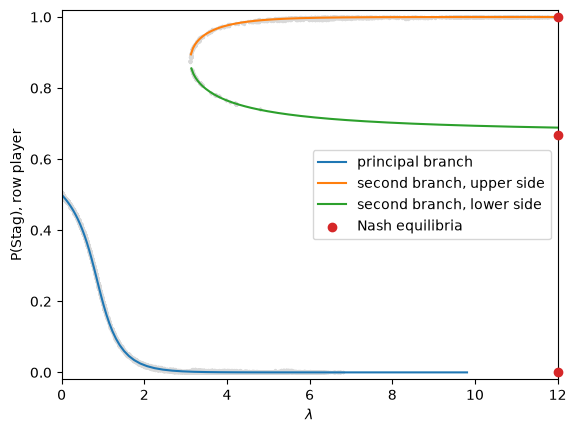

In [11]:
fig, ax = plt.subplots()
ax.scatter(on_locus[:, 0], on_locus[:, 1], s=2, color="0.85")
ax.plot(principal[:, 0], principal[:, 1], color="C0", label="principal branch")
ax.plot(branch_upper[:, 0], branch_upper[:, 1], color="C1", label="second branch, upper side")
ax.plot(branch_lower[:, 0], branch_lower[:, 1], color="C2", label="second branch, lower side")
ax.scatter([12, 12, 12], [0, 2 / 3, 1], marker="o", color="C3", zorder=5,
           clip_on=False, label="Nash equilibria")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("P(Stag), row player")
ax.set_xlim(0, 12)
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="center right")
plt.show()

The upper side of the second branch converges to the payoff-dominant equilibrium (Stag, Stag), and the lower side to the mixed equilibrium — neither of which can be found by following the correspondence from the centroid.
The two sides stop just short of each other at the fold, which fixed-$\lambda$ continuation cannot go around.

## A larger example: three players

Nothing above is specific to $2\times 2$ games.
The penalty needs only expected payoffs, which Gambit computes for any finite game, so the same functions apply unchanged to a larger game.

We use the three-player game of McKelvey and McLennan (1997) distributed with Gambit and also used in the [starting points](starting_points.ipynb) tutorial.
It has nine Nash equilibria, two of them totally mixed — the largest number of regular totally mixed equilibria possible in a game of this size.

In [12]:
g3 = gbt.read_nfg("../../2x2x2.nfg")
nash3 = [
    [np.array([float(eq[s]) for s in player.strategies]) for player in g3.players]
    for eq in gbt.nash.enumpoly_solve(g3).equilibria
]
totally_mixed = [i for i, eq in enumerate(nash3) if min(pr.min() for pr in eq) > 1e-9]
print(f"{len(nash3)} Nash equilibria; totally mixed: {totally_mixed}")
for i in totally_mixed:
    print(f"  #{i}: {[np.round(pr, 4).tolist() for pr in nash3[i]]}")

9 Nash equilibria; totally mixed: [7, 8]
  #7: [[0.5, 0.5], [0.4, 0.6], [0.25, 0.75]]
  #8: [[0.4, 0.6], [0.5, 0.5], [0.3333, 0.6667]]


Here the principal branch is of little help, for a different reason than in the stag hunt: `logit_solve_branch` stops early.

In [13]:
branch3 = gbt.qre.logit_solve_branch(g3)
final3 = [[float(branch3[-1].profile[s]) for s in player.strategies]
          for player in g3.players]
print(f"{len(branch3)} points; final lambda = {branch3[-1].lam:.4f}")
print(f"profile there:  {[np.round(pr, 4).tolist() for pr in final3]}")
print(f"max regret:     {float(g3.mixed_strategy_profile(final3).max_regret()):.4f}")

17 points; final lambda = 0.5968
profile there:  [[0.5, 0.5], [0.5, 0.5], [0.574, 0.426]]
max regret:     0.2130


The final point has a max regret of about $0.21$, so it is nowhere near a Nash equilibrium: the trace has stopped, not converged.
It stops because the branch passes through a *bifurcation* at this $\lambda$, where another branch crosses it and the Jacobian of the defining system is singular.
Arclength continuation handles folds, but a bifurcation is a genuinely harder obstacle, because the tangent to the path is not unique there.

The branch itself does not end.
Players 1 and 2 are each indifferent between their strategies whenever the *other* plays $(\tfrac12, \tfrac12)$, so $\sigma_1 = \sigma_2 = (\tfrac12, \tfrac12)$ satisfies their logit conditions at every $\lambda$, and player 3's expected payoffs are then constant.
This gives the whole principal branch in closed form, and we can check that it solves the system well past where the trace stopped.

In [14]:
centre = g3.mixed_strategy_profile([[0.5, 0.5]] * 3)
u3 = np.array([centre.strategy_value(s) for s in list(g3.players)[2].strategies])


def principal_at(lam):
    """Closed form for this game's principal branch: sigma_1 = sigma_2 = (1/2, 1/2)."""
    return [np.array([0.5, 0.5]), np.array([0.5, 0.5]), softmax(lam * u3)]


print(f"player 3's expected payoffs at sigma_1 = sigma_2 = (1/2, 1/2): {u3.tolist()}")
for lam in (branch3[-1].lam, 5.0, 25.0):
    residual = np.linalg.norm(qre_residual(pack(principal_at(lam)), g3, lam))
    print(f"  lambda = {lam:6.2f}:  residual = {residual:.1e}, "
          f"sigma_3 = {np.round(principal_at(lam)[2], 6).tolist()}")

player 3's expected payoffs at sigma_1 = sigma_2 = (1/2, 1/2): [3.5, 3.0]
  lambda =   0.60:  residual = 0.0e+00, sigma_3 = [0.574046, 0.425954]
  lambda =   5.00:  residual = 0.0e+00, sigma_3 = [0.924142, 0.075858]
  lambda =  25.00:  residual = 0.0e+00, sigma_3 = [0.999996, 4e-06]


So the principal branch runs to $\lambda \to \infty$ and converges to the equilibrium in which players 1 and 2 randomise uniformly and player 3 plays their first strategy.
Every other equilibrium lies on some other branch.

We can also see the crossing branch directly.
Perturbing off the principal branch and re-solving at the same $\lambda$ finds a second, asymmetric LQRE nearby; its distance from the principal branch shrinks to zero as $\lambda$ approaches the value where the trace stopped, and grows again on the other side.

In [15]:
rng_cross = np.random.default_rng(7)


def crossing_branch(lam, tries=150):
    """Distance to the nearest LQRE which is distinct from the principal branch."""
    base = principal_at(lam)
    best = None
    for _ in range(tries):
        start = [np.clip(pr + rng_cross.normal(0, 0.12, 2), 1e-6, 1 - 1e-6) for pr in base]
        sol = polish(g3, [pr / pr.sum() for pr in start], lam)
        if sol is None or np.linalg.norm(qre_residual(pack(sol), g3, lam)) > 1e-11:
            continue
        dev = max(np.max(np.abs(a - b)) for a, b in zip(sol, base, strict=True))
        if 1e-6 < dev < 0.25 and (best is None or dev < best):
            best = dev
    return best


for lam in (0.45, 0.55, branch3[-1].lam, 0.65, 0.85):
    dist = crossing_branch(lam)
    where = ("at" if lam == branch3[-1].lam
             else "below" if lam < branch3[-1].lam else "above")
    print(f"  lambda = {lam:.4f} ({where:>5}): "
          + (f"nearest distinct branch {dist:.4f} away" if dist
             else "no distinct branch nearby"))

  lambda = 0.4500 (below): nearest distinct branch 0.1121 away
  lambda = 0.5500 (below): nearest distinct branch 0.0294 away


  lambda = 0.5968 (   at): no distinct branch nearby
  lambda = 0.6500 (above): nearest distinct branch 0.0290 away


  lambda = 0.8500 (above): nearest distinct branch 0.1115 away


Sampling proceeds exactly as before, calling the same `sample_locus` with the new game.

In [16]:
rng3 = np.random.default_rng(20260801)
draws3 = sample_locus(g3, rng3, n_chains=48, n_iter=3_000)
on_locus3 = draws3[draws3[:, -1] > -1e-4]
len(on_locus3), len(draws3)

(92993, 144000)

With three players there is no longer a single picture in which to pick out branches by eye, so we seed systematically instead.
At each of several values of $\lambda$ we take the draws whose $\lambda^*$ is nearby, polish each at that exact $\lambda$, and keep the distinct solutions.
Draws are subsampled at random, because successive states of one chain are nearly identical.

Draws which have saturated at a vertex of the simplex are skipped: they are not usable as starting points, since the log-odds parameterisation is undefined where a probability is zero.

In [17]:
LAMBDA_SEEDS = (1.0, 1.5, 2.0)
SEED_WINDOW = 0.5  # how close a draw's lambda* must be to the seeding lambda
MAX_SEEDS = 150  # draws polished per seeding lambda
INTERIOR_TOL = 1e-6  # a probability below this counts as saturated
DEDUPE_TOL = 1e-4  # solutions closer than this are the same point


def interior(probs):
    return min(pr.min() for pr in probs) > INTERIOR_TOL


seeds3 = []  # (profile, lambda it was polished at)
for lam_seed in LAMBDA_SEEDS:
    near = on_locus3[
        (np.abs(on_locus3[:, 0] - lam_seed) < SEED_WINDOW)
        & np.all(on_locus3[:, 1:-1] > INTERIOR_TOL, axis=1)
        & np.all(on_locus3[:, 1:-1] < 1 - INTERIOR_TOL, axis=1)
    ]
    if len(near) > MAX_SEEDS:
        near = near[rng3.choice(len(near), MAX_SEEDS, replace=False)]
    for row in near:
        sol = polish(g3, [np.array([p, 1 - p]) for p in row[1:-1]], lam_seed)
        if sol is None or not interior(sol):
            continue
        if not any(np.max(np.abs(np.concatenate(sol) - np.concatenate(s))) < DEDUPE_TOL
                   for s, _ in seeds3):
            seeds3.append((sol, lam_seed))
print(f"{len(seeds3)} distinct LQRE found across lambda = {LAMBDA_SEEDS}")

22 distinct LQRE found across lambda = (1.0, 1.5, 2.0)


Each of these is a point on some branch.
Following each one upward in $\lambda$ shows which equilibrium its branch leads to.

In [18]:
LAMBDA_MAX_3 = 25.0


def follow_up(game, probs, lam, lam_max, step=LAMBDA_STEP):
    """Continue a branch upward in lambda; returns the lambdas and profiles reached."""
    lams, profiles = [lam], [probs]
    while lams[-1] < lam_max - 1e-9:
        nxt = polish(game, profiles[-1], min(lams[-1] + step, lam_max))
        if nxt is None or not interior(nxt):
            break  # no nearby solution, or the profile has saturated at a vertex
        lams.append(min(lams[-1] + step, lam_max))
        profiles.append(nxt)
    return np.array(lams), profiles


def nearest_equilibrium(probs):
    """Index of, and largest deviation from, the closest Nash equilibrium of `g3`."""
    dists = [max(np.max(np.abs(a - b)) for a, b in zip(probs, eq, strict=True))
             for eq in nash3]
    i = int(np.argmin(dists))
    return i, dists[i]


REACHED_TOL = 0.05

paths3 = [follow_up(g3, sol, lam, LAMBDA_MAX_3) for sol, lam in seeds3]
reached = {}
for lams, profiles in paths3:
    i, dist = nearest_equilibrium(profiles[-1])
    if dist < REACHED_TOL:
        reached.setdefault(i, []).append(lams[-1])
for i in sorted(reached):
    tag = " (totally mixed)" if i in totally_mixed else ""
    n = len(reached[i])
    print(f"  equilibrium #{i}: reached by {n} branch{'es' if n > 1 else ''}{tag}")
print(f"\nequilibria reached: {sorted(reached)} of {len(nash3)}; "
      f"totally mixed are {totally_mixed}")

  equilibrium #0: reached by 1 branch
  equilibrium #1: reached by 3 branches
  equilibrium #2: reached by 3 branches
  equilibrium #3: reached by 2 branches
  equilibrium #4: reached by 3 branches
  equilibrium #5: reached by 1 branch
  equilibrium #6: reached by 3 branches
  equilibrium #7: reached by 3 branches (totally mixed)
  equilibrium #8: reached by 3 branches (totally mixed)

equilibria reached: [0, 1, 2, 3, 4, 5, 6, 7, 8] of 9; totally mixed are [7, 8]


Plotting each player's probability of their first strategy against $\lambda$ shows the picture behind those numbers: a cloud of draws covering several branches, the principal branch ending abruptly at the bifurcation, and the continued branches running out to the equilibria.

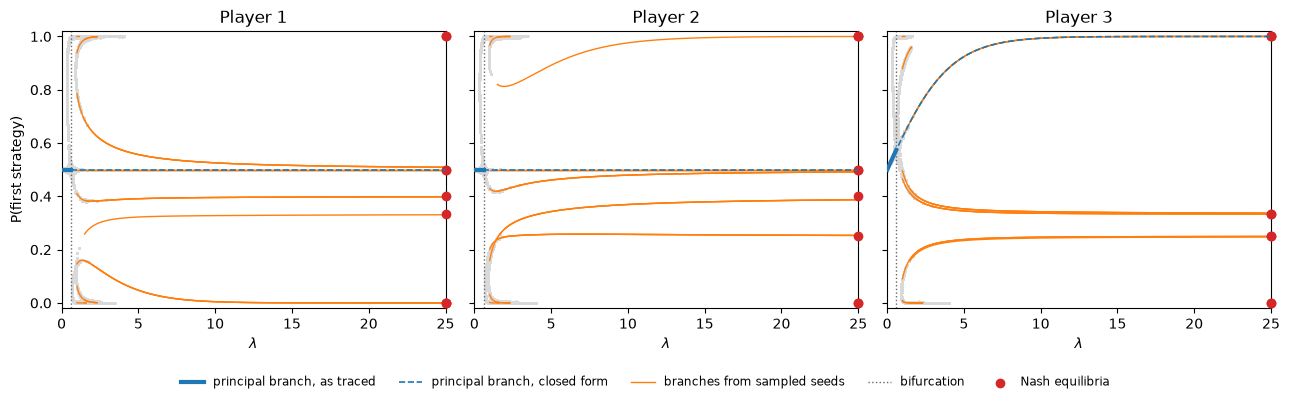

In [19]:
principal3 = np.array([[q.lam] + [float(q.profile[s]) for s in g3.strategies]
                       for q in branch3])
closed_lams = np.linspace(0, LAMBDA_MAX_3, 200)
closed_form = np.array([[pr[0] for pr in principal_at(lam)] for lam in closed_lams])

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
for k, ax in enumerate(axes):
    ax.scatter(on_locus3[:, 0], on_locus3[:, 1 + k], s=1, color="0.85")
    for lams, profiles in paths3:
        ax.plot(lams, [pr[k][0] for pr in profiles], color="C1", lw=1)
    ax.axvline(branch3[-1].lam, color="0.4", ls=":", lw=1)
    ax.plot(closed_lams, closed_form[:, k], color="C0", ls="--", lw=1.2, zorder=6)
    ax.plot(principal3[:, 0], principal3[:, 1 + 2 * k], color="C0", lw=3, zorder=7)
    ax.scatter([LAMBDA_MAX_3] * len(nash3), [eq[k][0] for eq in nash3],
               marker="o", color="C3", zorder=5, clip_on=False)
    ax.set_xlabel(r"$\lambda$")
    ax.set_title(f"Player {k + 1}")
    ax.set_xlim(0, LAMBDA_MAX_3)
    ax.set_ylim(-0.02, 1.02)
axes[0].set_ylabel("P(first strategy)")
axes[0].plot([], [], color="C0", lw=3, label="principal branch, as traced")
axes[0].plot([], [], color="C0", ls="--", lw=1.2, label="principal branch, closed form")
axes[0].plot([], [], color="C1", lw=1, label="branches from sampled seeds")
axes[0].axvline(np.nan, color="0.4", ls=":", lw=1, label="bifurcation")
axes[0].scatter([], [], marker="o", color="C3", label="Nash equilibria")
fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=5,
           fontsize="small", frameon=False)
plt.tight_layout(rect=(0, 0.07, 1, 1))
plt.show()

## Remarks

In both examples the sampling method locates branches of the correspondence which path-following from the centroid does not reach: in the stag hunt a second branch carrying the payoff-dominant and mixed equilibria, and in the three-player game branches carrying both totally mixed equilibria.
The three-player game also shows that the principal branch is not always traceable all the way to an equilibrium: Gambit's trace of it stops at a bifurcation, well short of any equilibrium, so the profile returned there is worth checking with `max_regret` rather than assuming it is an equilibrium.

Limitations of what is shown here, and natural directions from it:

- Fixed-$\lambda$ continuation cannot turn a fold, and stops once a probability saturates at a vertex, which is why several branches above end early. Gambit's own arclength tracer handles folds; its C++ implementation accepts arbitrary starting points, so it could in principle trace a whole branch from a polished point, although this is not currently exposed in the Python API.
- The random-walk sampler used here is only adequate for small games. [Bla24](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria) uses Hamiltonian Monte Carlo, and discusses performance in larger games.
- Nothing guarantees that sampling finds *every* branch. In the three-player game above the branches found lead to all nine equilibria, but that is an observation about this example, not a guarantee; drawing more samples, or seeding at more values of $\lambda$, is the only remedy on offer.
- [Bla24](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria) builds a Bayesian estimation procedure on top of this sampling approach, in which the penalty acts as an equilibrium constraint inside a posterior sampler; see also [BlaTur23](https://gambitproject.readthedocs.io/en/latest/biblio.html#articles-on-computation-of-equilibria) on maximum-likelihood estimation along the principal branch with `logit_estimate`.